# Class 6 — FDE Data Validation with FlashEats

Yesterday, you proved you could **retrieve** data from multiple systems.

Today the question is different:

> **Can we safely use that data to make a business decision?**

This is not a generic data-cleaning lab.

## FDE validation mindset

**Business claim → assumptions → validation contract → targeted checks → stakeholder clarification → PASS / WARN / FAIL → publish decision**

### Concepts

**1. Validation is decision-dependent**  
A field can be good enough for weekly reporting but unsafe for a live operational decision.

**2. Turn assumptions into contracts**  
Business assumption → data expectation → executable check → action.

**3. Separate three validation types**
- Technical: chronology, IDs, categories, mappings
- Semantic: what does a status or ETA actually mean?
- Organizational: who owns the KPI definition?

**4. Never silently fix ambiguity**  
Do not encode thresholds or category mappings without ownership.

**5. Output a validation gate**  
The deliverable is not merely a cleaned dataframe. It is a decision:
PASS / WARN / FAIL / UNKNOWN.

In [1]:
import json
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

# notebook runs from exercises/, the pack folder sits next to it
BASE = Path("FlashEats_Classroom_Pack_V2")
DB_PATH = BASE / "database" / "flasheats.db"

print("Database path:", DB_PATH)
print("Database exists:", DB_PATH.exists())

if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found at {DB_PATH}. Run the notebook from the exercises folder.")

Database path: FlashEats_Classroom_Pack_V2/database/flasheats.db
Database exists: True


## Load the updated FlashEats data

In [2]:
con = sqlite3.connect(BASE / "database" / "flasheats.db")

orders = pd.read_sql("SELECT * FROM orders", con)
restaurants = pd.read_sql("SELECT * FROM restaurants", con)
drivers = pd.read_sql("SELECT * FROM drivers", con)

tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")

with open(BASE / "data" / "client_metric_definitions.json", "r") as f:
    metric_notes = json.load(f)

print("orders:", orders.shape)
print("tickets:", tickets.shape)
print("restaurant_status:", restaurant_status.shape)

display(orders.head())
display(tickets.head())
display(restaurant_status.head())
print(json.dumps(metric_notes, indent=2))

orders: (1603, 13)
tickets: (202, 5)
restaurant_status: (502, 4)


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


,order_id,restaurant_id,status,last_updated_at
0,O00676,R040,READY,2026-08-17T13:29:00
1,O01506,R055,Ready,2026-08-27T16:37:00
2,O01484,R032,ready,2026-08-08T19:44:00
3,O00675,R012,handoff,2026-08-22T21:42:00
4,O00078,R027,unknown,2026-08-25T19:35:00


{
  "metric_under_review": "Late Delivery Rate",
  "leadership_claim": "Late Delivery Rate is 56%",
  "stakeholders": {
    "VP Operations": "Any delivered order after the promised ETA is late.",
    "Support Lead": "Only more than 10 minutes beyond ETA should count as meaningfully late.",
    "Finance": "Cancelled/refunded orders should not count in operational performance.",
    "Data Team": "Historical dashboard uses delivered orders with non-null actual delivery time."
  },
  "note": "No canonical KPI owner is formally documented."
}


# Challenge 1 — Can we defend the “56% late” claim?


Leadership says:

> **“Late Delivery Rate is 56%.”**

Before calculating anything, create a validation contract.

| Business assumption | Data expectation | How will you test it? | Severity if false |
|---|---|---|---|
| One row = one business order | `order_id` is unique in `orders`; duplicate copies (if any) are identical | compare row count with distinct `order_id`, then compare the columns inside each duplicate pair | High: duplicates inflate both numerator and denominator |
| Delivered orders have completion time | status `delivered` (any case) implies `actual_delivery_at` is not null | count delivered orders with a null `actual_delivery_at` | High: they silently drop out of the rate, or get counted as on time |
| Promised ETA is valid | `promised_eta` parses and is after `created_at` | parse with `format="mixed"`, count `promised_eta < created_at` | High: a promise before the order exists makes the delay meaningless |
| Event chronology is valid | `created_at <= pickup_at <= actual_delivery_at`; cancelled orders have no pickup/delivery | pairwise timestamp comparisons, split by status | Medium: few rows, but they end up at the top of the worst-delay list |
| “Late” has an agreed definition | one written definition (threshold + population) with a named owner | read `client_metric_definitions.json`, compute the rate under each view | High: the same data gives very different answers |

**Hint:** Don't start by cleaning. Ask: *what could make 56% misleading?*

In [3]:
# helpers used for every check in this notebook
TS_COLS = ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]

def parse_times(df, cols):
    df = df.copy()
    for c in cols:
        df[c] = pd.to_datetime(df[c], format="mixed", errors="coerce")
    return df

def check(name, n_bad, n_total, evidence, action):
    # PASS if nothing is wrong, WARN if under 5% of rows, FAIL otherwise
    status = "PASS" if n_bad == 0 else ("WARN" if n_bad / n_total < 0.05 else "FAIL")
    return {"check": name, "status": status, "bad": n_bad, "of": n_total, "evidence": evidence, "action": action}

print("Rows:", len(orders))
print("Unique orders:", orders["order_id"].nunique())
print(orders["final_status"].value_counts(dropna=False))

Rows: 1603
Unique orders: 1600
final_status
delivered    1530
cancelled      68
Delivered       5
Name: count, dtype: int64


In [4]:
o = parse_times(orders, TS_COLS)
print("Unparsed timestamps after format='mixed':", {c: int(o[c].isna().sum() - orders[c].isna().sum()) for c in TS_COLS})

dup_rows = o[o["order_id"].duplicated(keep=False)].sort_values("order_id")
conflict_cols = [c for c in o.columns if dup_rows.groupby("order_id")[c].nunique(dropna=False).max() > 1]
print("Duplicated order_ids:", dup_rows["order_id"].unique().tolist(), "| columns that disagree:", conflict_cols)
display(dup_rows[["order_id", "final_status", "traffic_bucket", "actual_delivery_at"]])

one = o.drop_duplicates("order_id", keep="first").copy()     # business grain = one row per order_id
one["status"] = one["final_status"].str.strip().str.lower()
delivered = one[one["status"] == "delivered"]
cancelled = one[one["status"] == "cancelled"]
has_actual = one[one["actual_delivery_at"].notna()]

contract_checks = pd.DataFrame([
    check("one row = one order", len(o) - one.shape[0], len(o),
          f"{len(o)} rows, {one.shape[0]} order_ids; copies differ in {conflict_cols}",
          "dedupe on order_id for counts; ask owner which traffic_bucket is right"),
    check("delivered orders have completion time", int(delivered["actual_delivery_at"].isna().sum()), len(delivered),
          "delivered but actual_delivery_at is null", "exclude from rate, report as unknown, ask order-platform owner"),
    check("promised_eta >= created_at", int((one["promised_eta"] < one["created_at"]).sum()), len(one),
          "promise earlier than order creation", "flag; exclude from worst-case lists"),
    check("created_at <= pickup_at", int((one["pickup_at"] < one["created_at"]).sum()), len(one),
          "pickup before order creation", "none needed"),
    check("pickup_at <= actual_delivery_at", int((has_actual["actual_delivery_at"] < has_actual["pickup_at"]).sum()), len(has_actual),
          "delivered before pickup", "flag; compare with driver app pickup event"),
    check("cancelled orders have no pickup", int(cancelled["pickup_at"].notna().sum()), len(cancelled),
          "cancelled orders with a pickup_at", "ask owner what pickup_at means on a cancelled order"),
    check("cancelled orders have no delivery time", int(cancelled["actual_delivery_at"].notna().sum()), len(cancelled),
          "cancelled orders with actual_delivery_at", "none needed"),
    check("'late' has an agreed definition + owner", 1, 1, metric_notes["note"],
          "needs a named KPI owner before publishing"),
])
display(contract_checks)

Unparsed timestamps after format='mixed': {'created_at': 0, 'promised_eta': 0, 'pickup_at': 0, 'actual_delivery_at': 0}
Duplicated order_ids: ['O00120', 'O00723', 'O01302'] | columns that disagree: ['traffic_bucket']


,order_id,final_status,traffic_bucket,actual_delivery_at
119,O00120,delivered,severe,2026-08-13 19:34:08.431508
1600,O00120,delivered,medium,2026-08-13 19:34:08.431508
722,O00723,delivered,medium,2026-08-05 22:04:30.928322
1601,O00723,delivered,high,2026-08-05 22:04:30.928322
1301,O01302,delivered,medium,2026-08-26 22:20:27.428561
1602,O01302,delivered,high,2026-08-26 22:20:27.428561


,check,status,bad,of,evidence,action
0,one row = one order,WARN,3,1603,"1603 rows, 1600 order_ids; copies differ in ['traffic_bucket']",dedupe on order_id for counts; ask owner which traffic_bucket is right
1,delivered orders have completion time,WARN,37,1532,delivered but actual_delivery_at is null,"exclude from rate, report as unknown, ask order-platform owner"
2,promised_eta >= created_at,WARN,4,1600,promise earlier than order creation,flag; exclude from worst-case lists
3,created_at <= pickup_at,PASS,0,1600,pickup before order creation,none needed
4,pickup_at <= actual_delivery_at,WARN,5,1495,delivered before pickup,flag; compare with driver app pickup event
5,cancelled orders have no pickup,FAIL,68,68,cancelled orders with a pickup_at,ask owner what pickup_at means on a cancelled order
6,cancelled orders have no delivery time,PASS,0,68,cancelled orders with actual_delivery_at,none needed
7,'late' has an agreed definition + owner,FAIL,1,1,No canonical KPI owner is formally documented.,needs a named KPI owner before publishing


Results of the contract checks:

- Grain (WARN): 1603 rows, 1600 order IDs. The 3 duplicate pairs differ only in `traffic_bucket`.
- Completion time (WARN): 37 of 1532 delivered orders (2.4%) have no `actual_delivery_at`.
- Promised ETA (WARN): 4 promises come before the order was created. All timestamps parse with `format="mixed"`.
- Chronology: no pickups before creation, 5 deliveries before pickup, and all 68 cancelled orders have a `pickup_at`. That last one is a FAIL because I don't know what the field records for them.
- Late definition (FAIL): no documented KPI owner, and four different stakeholder views.

So 56% could mislead: it treats a 1-minute miss like a 60-minute one, it leaves out the 37 unknown orders, and it depends on which definition was used.

Questions I would take to the owners:
- Why do 37 delivered orders have no delivery time?
- What does `pickup_at` mean on a cancelled order?
- Why are O00120, O00723 and O01302 stored twice, and which traffic value is right?
- Can `promised_eta` be overwritten after the order is created?
- Who owns Late Delivery Rate?

# Challenge 2 — Stakeholders disagree on “late”


Read `client_metric_definitions.json`.

Calculate the metric under at least three definitions:
- any delay > 0 minutes,
- delay > 10 minutes,
- historical-style delivered/non-null population.

| Definition | Late rate | Business meaning |
|---|---:|---|

Then answer:

> **Which one should leadership publish, and who must own that decision?**

In [5]:
analysis = orders.drop_duplicates("order_id", keep="first").copy()

for c in ["promised_eta", "actual_delivery_at"]:
    analysis[c] = pd.to_datetime(analysis[c], format="mixed", errors="coerce")

analysis["delay_min"] = (analysis["actual_delivery_at"] - analysis["promised_eta"]).dt.total_seconds() / 60
analysis["status"] = analysis["final_status"].str.strip().str.lower()

def late_rate(df, threshold, population):
    # missing delay counts as not late
    pop = df[population(df)]
    late = int((pop["delay_min"] > threshold).sum())
    return late, len(pop), round(100 * late / len(pop), 1)

delivered_nonnull = lambda d: (d["status"] == "delivered") & d["actual_delivery_at"].notna()
finance_pop = lambda d: (d["status"] != "cancelled") & d["actual_delivery_at"].notna()   # refunds not in this table
all_delivered = lambda d: d["status"] == "delivered"
all_orders = lambda d: d["status"].notna()

definitions = [
    ("VP Ops: delivered after ETA by any amount", "> 0 min\n(VP Ops)", 0, delivered_nonnull, "every missed promise counts"),
    ("Data team historical: delivered, non-null actual, delay > 0", "historical\n(Data team)", 0, delivered_nonnull, "what the old dashboard used"),
    ("Finance: exclude cancelled (refunds not identifiable)", "excl. cancelled\n(Finance)", 0, finance_pop, "operational orders only"),
    ("Support: delay > 10 min", "> 10 min\n(Support)", 10, delivered_nonnull, "delays a customer really notices"),
    ("Sensitivity: delay > 5 min", "> 5 min", 5, delivered_nonnull, "not a stakeholder view"),
    ("Sensitivity: missing actual counted as on time", "nulls = on time", 0, all_delivered, "37 unknown orders treated as fine"),
    ("Naive: all 1600 orders in denominator", "all orders", 0, all_orders, "mixes in cancelled + unknown"),
]
rows = []
for name, label, thr, pop, meaning in definitions:
    late, n, pct = late_rate(analysis, thr, pop)
    rows.append({"definition": name, "label": label, "threshold_min": thr, "late": late, "denominator": n,
                 "late_rate_pct": pct, "business_meaning": meaning})
def_table = pd.DataFrame(rows)
display(def_table.drop(columns="label"))

# what does the historical definition give on the raw, un-deduplicated table?
raw = parse_times(orders, ["promised_eta", "actual_delivery_at"])
raw["delay_min"] = (raw["actual_delivery_at"] - raw["promised_eta"]).dt.total_seconds() / 60
raw_pop = raw[raw["actual_delivery_at"].notna()]
print(f"Historical definition on raw rows (no dedup): {(raw_pop['delay_min'] > 0).sum()} / {len(raw_pop)} = {100 * (raw_pop['delay_min'] > 0).mean():.1f}%")
exact = analysis[(analysis["final_status"] == "delivered") & analysis["actual_delivery_at"].notna()]
print(f"Case-sensitive filter final_status == 'delivered': {(exact['delay_min'] > 0).sum()} / {len(exact)} = {100 * (exact['delay_min'] > 0).mean():.1f}%")
print("Can refunded orders be identified in the orders table?", "refund" in " ".join(orders.columns).lower())

,definition,threshold_min,late,denominator,late_rate_pct,business_meaning
0,VP Ops: delivered after ETA by any amount,0,843,1495,56.4,every missed promise counts
1,"Data team historical: delivered, non-null actual, delay > 0",0,843,1495,56.4,what the old dashboard used
2,Finance: exclude cancelled (refunds not identifiable),0,843,1495,56.4,operational orders only
3,Support: delay > 10 min,10,349,1495,23.3,delays a customer really notices
4,Sensitivity: delay > 5 min,5,560,1495,37.5,not a stakeholder view
5,Sensitivity: missing actual counted as on time,0,843,1532,55.0,37 unknown orders treated as fine
6,Naive: all 1600 orders in denominator,0,843,1600,52.7,mixes in cancelled + unknown


Historical definition on raw rows (no dedup): 844 / 1498 = 56.3%
Case-sensitive filter final_status == 'delivered': 840 / 1490 = 56.4%
Can refunded orders be identified in the orders table? False


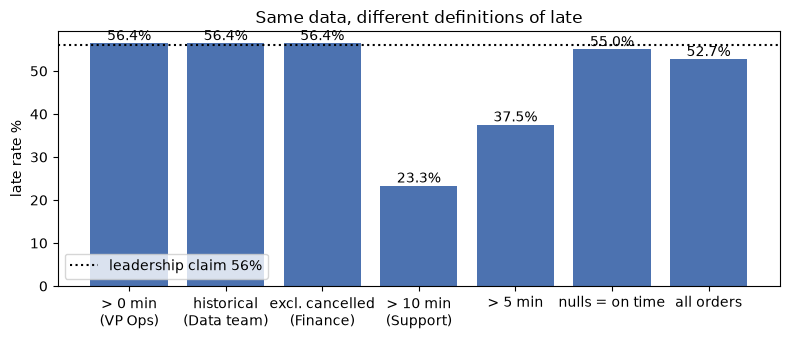

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(def_table["label"], def_table["late_rate_pct"], color="#4C72B0")
ax.axhline(56, color="black", linestyle=":", label="leadership claim 56%")
ax.bar_label(bars, fmt="%.1f%%")
ax.set_ylabel("late rate %")
ax.set_title("Same data, different definitions of late")
ax.legend()
plt.tight_layout()
plt.show()

| Definition | Late rate | Business meaning |
|---|---:|---|
| VP Ops: any delay > 0 (843/1495) | 56.4% | every missed promise counts |
| Data team historical: delivered, non-null time (843/1495) | 56.4% | old dashboard; same as VP Ops here |
| Finance: exclude cancelled/refunded (843/1495) | 56.4% | refunds aren't in `orders`, so that part is unknown |
| Support: > 10 min (349/1495) | 23.3% | delays customers notice |
| > 5 min (560/1495) | 37.5% | sensitivity only |
| missing times counted as on time (843/1532) | 55.0% | sensitivity only |
| all 1600 orders as denominator (843/1600) | 52.7% | mixes in cancelled and unknown |

56% is reproducible: delay > 0 min on delivered orders with a time gives 56.4%, or 56.3% (844/1498) on the raw table.

I'd publish the > 0 min rate because it matches the promise made to the customer, but always with its denominator and the > 10 min rate (23.3%) next to it. Leadership has to pick the owner. My suggestion would be VP Operations since they run delivery, with Support and Finance agreeing the definition. Today nobody is documented as owner.

# Challenge 3 — Validate categories without cleaning by instinct


Inspect:
- `final_status`
- `traffic_bucket`
- restaurant `status`
- support-ticket `category`

For each:
1. list observed values,
2. identify representation differences,
3. decide what is safe to normalize,
4. identify what requires owner confirmation.

Remember:

> `"Delivered"` vs `"delivered"` is likely representation.  
> `"handoff"` vs `"handed_off"` may be semantics.

In [7]:
for col in ["final_status", "traffic_bucket"]:
    print("\n", col)
    print(orders[col].value_counts(dropna=False))

print("\nRestaurant status")
print(restaurant_status["status"].value_counts(dropna=False))

print("\nSupport category")
print(tickets["category"].value_counts(dropna=False))


 final_status
final_status
delivered    1530
cancelled      68
Delivered       5
Name: count, dtype: int64

 traffic_bucket
traffic_bucket
medium    635
high      448
low       381
severe    136
HIGH        3
Name: count, dtype: int64

Restaurant status
status
preparing     171
handed_off    168
ready         157
ready           2
READY           1
Ready           1
handoff         1
unknown         1
Name: count, dtype: int64

Support category
category
late_delivery        38
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64


In [8]:
def profile_categories(series, name):
    s = series.astype("string")
    norm = s.str.strip().str.lower().str.replace(" ", "_")
    out = pd.DataFrame({"raw_value": s, "normalised": norm}).value_counts().reset_index(name="rows")
    out.insert(0, "field", name)
    out["changed"] = out["raw_value"] != out["normalised"]
    return out

cat_profile = pd.concat([
    profile_categories(orders["final_status"], "final_status"),
    profile_categories(orders["traffic_bucket"], "traffic_bucket"),
    profile_categories(restaurant_status["status"], "restaurant status"),
    profile_categories(tickets["category"], "ticket category"),
], ignore_index=True)
display(cat_profile.sort_values(["field", "normalised"]))

summary = cat_profile.groupby("field").agg(raw_values=("raw_value", "nunique"), after_normalising=("normalised", "nunique"))
display(summary)

# before merging ticket labels, read what the customer actually wrote
odd = ~tickets["category"].isin(["late_delivery", "eta_changed", "restaurant_delay", "ready_but_waiting", "status_mismatch", "driver_not_moving"])
display(tickets.loc[odd, ["ticket_id", "category", "customer_message"]])

,field,raw_value,normalised,rows,changed
1,final_status,cancelled,cancelled,68,False
0,final_status,delivered,delivered,1530,False
2,final_status,Delivered,delivered,5,True
9,restaurant status,handed_off,handed_off,168,False
14,restaurant status,handoff,handoff,1,False
8,restaurant status,preparing,preparing,171,False
10,restaurant status,ready,ready,157,False
11,restaurant status,ready,ready,2,True
12,restaurant status,READY,ready,1,True
13,restaurant status,Ready,ready,1,True


,raw_values,after_normalising
field,,
final_status,3,2
restaurant status,8,5
ticket category,9,7
traffic_bucket,5,4


,ticket_id,category,customer_message
3,T00004,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,late_delivery,My order is already past the promised time.
5,T00006,ETA issue,The rider has not moved for 15 minutes.


| Field | Observed values | Safe to normalise (representation) | Needs owner confirmation (semantics) |
|---|---|---|---|
| `final_status` | delivered 1530, Delivered 5, cancelled 68 | `Delivered` -> `delivered` | whether "cancelled" also covers refunded orders |
| `traffic_bucket` | medium, high, low, severe, HIGH (3) | `HIGH` -> `high` | which value is right for the 3 duplicate orders; whether the bucket is measured at order time or at delivery |
| restaurant `status` | 8 raw values -> 5 after normalising | `ready `, `READY`, `Ready` -> `ready` | `handoff` (1) vs `handed_off` (168) is probably the same thing, but it might be a different app step; `unknown` (1) stays unknown |
| ticket `category` | 9 raw values -> 7 after normalising | `late_delivery ` -> `late_delivery` (message matches) | `Late Delivery` (T00004) and `ETA issue` (T00006) both have the message "The rider has not moved for 15 minutes", so they may really be `driver_not_moving`; Support should decide |

My rule was to change only case and surrounding spaces, which are clearly typing differences. Anything that changes the *word* (`handoff` vs `handed_off`, `ETA issue` vs `eta_changed`) could have a different meaning, so I leave it as its own value until the owner confirms. Reading the messages mattered here: `Late Delivery` looks like a pure case difference, but its text points to a different category. None of these affect the headline late rate except `Delivered`. Filtering on lowercase `delivered` only drops those 5 orders and gives 840 / 1490 = 56.4% (printed in Challenge 2), so here it barely matters.

# Challenge 4 — Cross-source integrity


Validate mappings:
- `orders.restaurant_id` → restaurants
- `orders.driver_id` → drivers
- `tickets.order_id` → orders
- `restaurant_status.order_id` → orders

Produce:

| Relationship | Coverage % | Status | Risk |
|---|---:|---|---|

Then discuss:

> If 1% is unmapped, is that acceptable?

It depends on which business decision uses those records.

In [9]:
def coverage(child, parent, key, name):
    # share of child rows whose key exists in the parent; null keys count as unmapped
    keys = child[key]
    matched = int(keys.isin(set(parent[key].dropna())).sum())
    pct = round(100 * matched / len(keys), 2)
    status = "PASS" if pct == 100 else ("WARN" if pct >= 95 else "FAIL")
    return {"relationship": name, "rows": len(keys), "null_keys": int(keys.isna().sum()),
            "unmatched_non_null": len(keys) - matched - int(keys.isna().sum()), "coverage_pct": pct, "status": status}

orders_1 = orders.drop_duplicates("order_id", keep="first")
rs_1 = restaurant_status.drop_duplicates()
print("restaurant_status exact duplicate rows:", len(restaurant_status) - len(rs_1),
      "| order_ids with more than one status row after that:", int(rs_1["order_id"].duplicated().sum()))

cov = pd.DataFrame([
    coverage(orders_1, restaurants, "restaurant_id", name="orders.restaurant_id -> restaurants"),
    coverage(orders_1, drivers, "driver_id", name="orders.driver_id -> drivers"),
    coverage(tickets.drop_duplicates(), orders_1, "order_id", name="tickets.order_id -> orders"),
    coverage(rs_1, orders_1, "order_id", name="restaurant_status.order_id -> orders"),
    coverage(orders_1, rs_1, "order_id", name="orders -> restaurant_status (reverse)"),
    coverage(orders_1, tickets, "order_id", name="orders -> tickets (reverse, info only)"),
])
risk = {
    "orders.restaurant_id -> restaurants": "per-restaurant late rates miss the unmapped orders",
    "orders.driver_id -> drivers": "per-driver analysis; also orders.driver_id is the original driver, not the current one",
    "tickets.order_id -> orders": "unlinked tickets cannot be tied to an outcome",
    "restaurant_status.order_id -> orders": "status rows that point nowhere",
    "orders -> restaurant_status (reverse)": "most orders have no restaurant status at all, so restaurant accountability is partial",
    "orders -> tickets (reverse, info only)": "expected to be low, most orders get no ticket",
}
cov["risk"] = cov["relationship"].map(risk)
display(cov)

m = rs_1.merge(orders_1[["order_id", "restaurant_id"]], on="order_id", suffixes=("_status", "_order"))
print(f"orders with a null restaurant_id: {orders_1['restaurant_id'].isna().sum()} = {100 * orders_1['restaurant_id'].isna().mean():.2f}% of orders")
print("restaurant_status.restaurant_id agrees with orders.restaurant_id:", int((m["restaurant_id_status"] == m["restaurant_id_order"]).sum()), "of", len(m))

restaurant_status exact duplicate rows: 2 | order_ids with more than one status row after that: 0


,relationship,rows,null_keys,unmatched_non_null,coverage_pct,status,risk
0,orders.restaurant_id -> restaurants,1600,3,0,99.81,WARN,per-restaurant late rates miss the unmapped orders
1,orders.driver_id -> drivers,1600,3,0,99.81,WARN,"per-driver analysis; also orders.driver_id is the original driver, not the current one"
2,tickets.order_id -> orders,201,3,0,98.51,WARN,unlinked tickets cannot be tied to an outcome
3,restaurant_status.order_id -> orders,500,0,0,100.00,PASS,status rows that point nowhere
4,orders -> restaurant_status (reverse),1600,0,1100,31.25,FAIL,"most orders have no restaurant status at all, so restaurant accountability is partial"
5,"orders -> tickets (reverse, info only)",1600,0,1402,12.38,FAIL,"expected to be low, most orders get no ticket"


orders with a null restaurant_id: 3 = 0.19% of orders
restaurant_status.restaurant_id agrees with orders.restaurant_id: 500 of 500


| Relationship | Coverage % | Status | Risk |
|---|---:|---|---|
| `orders.restaurant_id` -> restaurants | 99.81% | WARN | 3 orders have a null restaurant, so they're missing from per-restaurant stats |
| `orders.driver_id` -> drivers | 99.81% | WARN | 3 null drivers; also, from the Class 5 dispatch data, this column holds the original driver, not the one who delivered |
| `tickets.order_id` -> orders | 98.51% | WARN | 3 of 201 tickets have no order_id and can't be tied to an outcome |
| `restaurant_status.order_id` -> orders | 100.00% | PASS | fine after removing 2 exact duplicate rows |
| orders -> `restaurant_status` (reverse) | 31.25% | FAIL | 1100 of 1600 orders have no restaurant status at all |

All non-null keys match, so there are no orphan IDs. The gaps are nulls, plus one big coverage gap in the other direction. The `restaurant_id` in restaurant_status agrees with the orders table for all 500 orders.

**Is 1% unmapped acceptable?** For the company-wide weekly late rate, yes: 3 orders out of 1600 (0.19%) cannot move the number. For ranking or penalising restaurants it is less clear. If the 3 missing orders all belong to one small restaurant, its rate could change a lot. For restaurant accountability the real problem is the 31.25% coverage of restaurant status. For answering individual customers, every unlinked ticket is a customer we can't follow up. So whether 1% is acceptable depends on which decision uses the data.

# Challenge 5 — Freshness is an SLA question


Use `restaurant_status.csv`.

Determine whether status updates are fresh enough for:
- weekly analytics,
- live customer ETA,
- restaurant accountability.

The same record may be acceptable for one use case and unsafe for another.

**Hint:** join status records to order lifecycle timestamps and inspect timing.

In [10]:
rs = rs_1.copy()
rs["status_norm"] = rs["status"].str.strip().str.lower()
rs["last_updated_at"] = pd.to_datetime(rs["last_updated_at"], format="mixed", errors="coerce")

life = parse_times(orders_1, TS_COLS)[["order_id", "final_status"] + TS_COLS]
fr = rs.merge(life, on="order_id", how="left", validate="many_to_one")
fr = fr.merge(restaurants[["restaurant_id", "manual_status_updates"]], on="restaurant_id", how="left")

fr["min_after_created"] = (fr["last_updated_at"] - fr["created_at"]).dt.total_seconds() / 60
fr["min_vs_pickup"] = (fr["last_updated_at"] - fr["pickup_at"]).dt.total_seconds() / 60
fr["min_before_delivery"] = (fr["actual_delivery_at"] - fr["last_updated_at"]).dt.total_seconds() / 60

print("status rows:", len(fr), "| orders covered:", fr["order_id"].nunique(), "of", len(orders_1))
print("timestamps with seconds != 0:", int((fr["last_updated_at"].dt.second != 0).sum()), "(minute precision only)")
display(fr[["min_after_created", "min_vs_pickup", "min_before_delivery"]].describe().round(1))

flags = pd.DataFrame([
    {"flag": "updated before the order was created", "rows": int((fr["min_after_created"] < 0).sum())},
    {"flag": "updated after delivery", "rows": int((fr["min_before_delivery"] < 0).sum())},
    {"flag": "still 'preparing' although last update is after pickup", "rows": int(((fr["status_norm"] == "preparing") & (fr["min_vs_pickup"] > 0)).sum())},
    {"flag": "'handed_off' but last update is before pickup", "rows": int(((fr["status_norm"] == "handed_off") & (fr["min_vs_pickup"] < 0)).sum())},
    {"flag": "last update > 30 min before pickup (stale by pickup time)", "rows": int((fr["min_vs_pickup"] < -30).sum())},
])
display(flags)

print("Median minutes from last status update to pickup, by status:")
display(fr.groupby("status_norm")["min_vs_pickup"].agg(["count", "median"]).round(1))
print("By manual_status_updates flag of the restaurant:")
display(fr.groupby("manual_status_updates")["min_vs_pickup"].agg(["count", "median"]).round(1))

status rows: 500 | orders covered: 500 of 1600
timestamps with seconds != 0: 0 (minute precision only)


,min_after_created,min_vs_pickup,min_before_delivery
count,500.0,500.0,473.0
mean,16.7,-10.5,56.8
std,37.8,39.0,41.4
min,-354.0,-385.8,5.3
25%,12.0,-16.8,40.3
50%,20.0,-6.4,53.5
75%,28.0,3.2,66.1
max,35.0,25.4,434.6


,flag,rows
0,updated before the order was created,5
1,updated after delivery,0
2,still 'preparing' although last update is after pickup,49
3,'handed_off' but last update is before pickup,112
4,last update > 30 min before pickup (stale by pickup time),26


Median minutes from last status update to pickup, by status:


,count,median
status_norm,,
handed_off,168,-6.4
handoff,1,8.1
preparing,170,-7.3
ready,160,-5.2
unknown,1,-3.2


By manual_status_updates flag of the restaurant:


,count,median
manual_status_updates,,
0,311,-6.5
1,189,-6.3


The status file has one row per order for 500 of the 1600 orders (after dropping 2 exact duplicates). It keeps only the last status, at minute precision. The median last update is 20.0 min after the order was created and 6.4 min before pickup.

Problems:
- 5 rows were updated before the order existed (one by 354 min).
- 49 of 170 `preparing` rows were last updated after pickup, so the status was stale.
- 112 of 168 `handed_off` rows are timestamped before the driver's pickup. That could be normal or a clock difference, I'd ask.
- 26 rows were last updated more than 30 min before pickup.

| Use case | Verdict | Why |
|---|---|---|
| Weekly analytics | WARN | fine as background, not as a KPI source |
| Live customer ETA | FAIL | no status history, stale `preparing` rows, updates before the order |
| Restaurant accountability | FAIL | 31.25% coverage, no food-ready time, can't separate restaurant from driver |

# Challenge 6 — Build the validation gate


Summarize the investigation:

| Check | Status | Evidence | Action |
|---|---|---|---|
| Business grain | WARN | 1603 rows for 1600 orders; 3 duplicate pairs disagree on `traffic_bucket` | dedupe on `order_id` (done); order platform to say which copy is right |
| Timestamp chronology | WARN | 37 delivered with no time, 4 promises before creation, 5 deliveries before pickup, 68 cancelled with `pickup_at` | report 37 as unknown, flag the 9, clarify `pickup_at` on cancelled orders |
| KPI definition | FAIL | 4 stakeholder views, 23.3% to 56.4%; no documented owner | leadership names an owner who signs off one written definition |
| Category semantics | WARN | case/space variants are safe; `handoff`, `unknown`, `ETA issue`, `Late Delivery` are not | normalise case only; owners confirm the 4 semantic values |
| Cross-source mapping | WARN | 99.81% / 99.81% / 98.51% / 100%; restaurant status covers 31.25% of orders | fine for the KPI; not enough for per-restaurant accountability |
| Freshness | FAIL | single snapshot per order, minute precision, stale `preparing` rows | OK as weekly background only; not for live ETA or restaurant accountability |

Use only:
**PASS / WARN / FAIL / UNKNOWN**

Finally answer:

> **Should leadership publish “Late Delivery Rate = 56%” today?**

What exactly must happen before the metric becomes publishable?

In [11]:
gate = pd.DataFrame([
    ["Business grain", "WARN", "1603 rows for 1600 orders; 3 duplicate pairs disagree on traffic_bucket", "dedupe on order_id; ask which copy is right"],
    ["Timestamp chronology", "WARN", "37 delivered without time, 4 promises before creation, 5 deliveries before pickup, 68 cancelled with pickup_at", "report 37 as unknown, flag the 9, clarify pickup_at"],
    ["KPI definition", "FAIL", "4 stakeholder views, 23.3% to 56.4%, no documented owner", "leadership names an owner who signs off one definition"],
    ["Category semantics", "WARN", "case/space variants safe; handoff, unknown, ETA issue, Late Delivery need an owner", "normalise case only"],
    ["Cross-source mapping", "WARN", "99.81% / 99.81% / 98.51% / 100%; status covers 31.25% of orders", "fine for the KPI, not for restaurant blame"],
    ["Freshness", "FAIL", "one last-status row per order, minute precision, stale preparing rows", "OK as weekly background only; not for live ETA or accountability"],
], columns=["check", "status", "evidence", "action"])
display(gate)

validation_report = {
    "business_grain": "WARN",
    "timestamp_chronology": "WARN",
    "kpi_definition": "FAIL",
    "category_semantics": "WARN",
    "cross_source_mapping": "WARN",
    "freshness": "FAIL",
    "publish_56_percent": "FAIL",
}
print(json.dumps(validation_report, indent=2))

,check,status,evidence,action
0,Business grain,WARN,1603 rows for 1600 orders; 3 duplicate pairs disagree on traffic_bucket,dedupe on order_id; ask which copy is right
1,Timestamp chronology,WARN,"37 delivered without time, 4 promises before creation, 5 deliveries before pickup, 68 cancelled with pickup_at","report 37 as unknown, flag the 9, clarify pickup_at"
2,KPI definition,FAIL,"4 stakeholder views, 23.3% to 56.4%, no documented owner",leadership names an owner who signs off one definition
3,Category semantics,WARN,"case/space variants safe; handoff, unknown, ETA issue, Late Delivery need an owner",normalise case only
4,Cross-source mapping,WARN,99.81% / 99.81% / 98.51% / 100%; status covers 31.25% of orders,"fine for the KPI, not for restaurant blame"
5,Freshness,FAIL,"one last-status row per order, minute precision, stale preparing rows",OK as weekly background only; not for live ETA or accountability


{
  "business_grain": "WARN",
  "timestamp_chronology": "WARN",
  "kpi_definition": "FAIL",
  "category_semantics": "WARN",
  "cross_source_mapping": "WARN",
  "freshness": "FAIL",
  "publish_56_percent": "FAIL"
}


**Should leadership publish "Late Delivery Rate = 56%" today? No.**

I can reproduce the number: 843 of 1495 delivered orders with a delivery time were late by any amount (56.4%), and 844 / 1498 = 56.3% on the raw table without dedup, which is probably where the 56% came from. What's missing is an owner and a written definition; on the same data Support's definition gives 23.3%.

Before it can be published:
1. Leadership names a KPI owner who signs off one definition (threshold + population).
2. The number goes out with its definition and denominator, e.g. "56.4% of delivered orders arrived after the promised ETA (843 of 1495; 23.3% more than 10 min late)".
3. The 37 delivered orders without a delivery time are shown as unknown and explained by the order platform owner.
4. The 9 chronology problems, the `pickup_at` on cancelled orders and the 3 duplicate orders get explained or fixed at the source.
5. Finance says where refunds are recorded, or agrees to leave them in.

Freshness is also FAIL, but restaurant status isn't an input to the late rate, so it blocks live ETA and restaurant accountability rather than this KPI. Chronology is WARN overall even though the cancelled-pickup check failed, because cancelled orders are outside the rate.

# Final takeaway

The job was not to make the data look clean.

The job was to decide:

> **Is this data safe enough for this decision, and what remains unresolved?**

In [12]:
con.close()